# Phase 0 : Data Pipeline and Validation

**Project:** A data-driven surrogate for airfoil shape optimization, built on the AirfRANS benchmark
**Author:** Muhammad Uns Haider Shah

## Context
The project trains a neural-network surrogate on AirfRANS RANS simulations, uses it to drive airfoil shape optimization, and studies when the surrogate's proposed optimum can be trusted. Surrogates are evaluated primarily by their ability to **rank designs** (Spearman correlation of predicted vs. true $C_L$, $C_D$), since that, rather than field error, determines usefulness inside an optimization loop.

## This notebook
Phase 0 builds and validates the data pipeline used by all later phases:
1. Load the AirfRANS *scarce* task and characterise the training distribution.
2. Visualise flow fields and near-wall mesh resolution.
3. Extract surface pressure distributions ($C_p$).
4. Integrate surface pressure to force coefficients, validated against the reference implementation in the `airfrans` library.
5. Compute training-set normalisation statistics for the surrogate.

**Runtime:** Google Colab, CPU. The dataset (~9 GB) is cached in Google Drive after the first run; set `USE_DRIVE = False` to download without caching.

## 1. Environment

In [ ]:
# pyvista is pinned: 0.49+ requires a newer IPython than the Colab runtime provides
!pip install -q airfrans "pyvista==0.48.0" "vtk<9.7"
import airfrans as af
import numpy as np
import matplotlib.pyplot as plt
import os, glob, json
print('airfrans imported OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 10.2 MB/s eta 0:00:00
airfrans imported OK


## 2. Dataset acquisition
The pre-processed AirfRANS dataset (the version used in the original benchmark paper) is downloaded once and cached in Google Drive. Later sessions restore it from the cache. The cache is written only after a successful extraction.

In [ ]:
import shutil, zipfile
from google.colab import drive

USE_DRIVE = True
DRIVE_DIR = '/content/drive/MyDrive/airfrans'
DRIVE_ZIP = f'{DRIVE_DIR}/Dataset.zip'
ROOT_DL   = '/content/airfrans_data'
LOCAL_ZIP = f'{ROOT_DL}/Dataset.zip'

def have_data():
    return bool(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True))

def gb(path):
    return os.path.getsize(path) / 1e9

if USE_DRIVE:
    drive.mount('/content/drive')
    os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(ROOT_DL, exist_ok=True)

if have_data():
    print('Dataset already extracted on this machine.')
elif USE_DRIVE and os.path.exists(DRIVE_ZIP):
    print(f'Copying {gb(DRIVE_ZIP):.1f} GB zip from Drive (unzipping from local disk is much faster)...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall(ROOT_DL)
else:
    print('No cached copy found. Downloading from the AirfRANS server (slow, one time only)...')
    af.dataset.download(root=ROOT_DL, file_name='Dataset', unzip=True, OpenFOAM=False)

# Cache to Drive if it isn't there yet. This only runs after a successful unzip,
# so a broken or partial download never gets saved.
if USE_DRIVE and os.path.exists(LOCAL_ZIP) and have_data():
    if not os.path.exists(DRIVE_ZIP) or gb(DRIVE_ZIP) != gb(LOCAL_ZIP):
        print(f'Saving {gb(LOCAL_ZIP):.1f} GB zip to Drive (10-20 min, one time only)...')
        shutil.copy(LOCAL_ZIP, DRIVE_ZIP)
    print(f'Drive copy OK: {gb(DRIVE_ZIP):.2f} GB  (local {gb(LOCAL_ZIP):.2f} GB)')

print('Data ready:', have_data())

Mounted at /content/drive
Copying 10.0 GB zip from Drive (unzipping from local disk is much faster)...
Unzipping...
Drive copy OK: 10.03 GB  (local 10.03 GB)
Data ready: True


In [ ]:
# The loader needs the folder that contains manifest.json. Find it rather than guessing.
ROOT = os.path.dirname(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True)[0])
print('Dataset root:', ROOT)

# Free local disk space; the zip is cached in Drive if USE_DRIVE is set
zip_path = f'{ROOT_DL}/Dataset.zip'
if os.path.exists(zip_path):
    os.remove(zip_path)

with open(f'{ROOT}/manifest.json') as f:
    manifest = json.load(f)
for k, v in manifest.items():
    print(f'{k:15s} {len(v):5d} simulations')

Dataset root: /content/airfrans_data/Dataset
full_train        800 simulations
scarce_train      200 simulations
reynolds_train    504 simulations
aoa_train         804 simulations
full_test         200 simulations
reynolds_test     496 simulations
aoa_test          196 simulations


The *scarce* task has its own training list but shares its test set with the *full* task, so test metrics from a scarce-trained model are directly comparable with full-task baselines on identical cases.

## 3. Utilities
Surface-node ordering, name parsing, and pressure-force integration. The integration routine is independent of node ordering and normal orientation; it was verified on a synthetic NACA 2412 surface against the exact result for a linear pressure field ($\oint p\,\mathbf{n}\,ds = A\,\hat{\mathbf{y}}$ for $p = y$).

In [ ]:
import numpy as np

def order_surface(pos, normals):
    """Return indices that walk the airfoil surface as a closed loop:
    upper surface leading edge -> trailing edge, then lower surface trailing edge -> leading edge.
    Works whichever way the normals point (inward or outward)."""
    g1 = np.where(normals[:, 1] < 0)[0]
    g2 = np.where(normals[:, 1] >= 0)[0]
    # The upper-surface group is the one sitting higher on average
    upper, lower = (g1, g2) if pos[g1, 1].mean() > pos[g2, 1].mean() else (g2, g1)
    upper = upper[np.argsort(pos[upper, 0])]     # LE -> TE
    lower = lower[np.argsort(-pos[lower, 0])]    # TE -> LE
    return np.concatenate([upper, lower]), len(upper)

def pressure_force_coefficients(pos, normals, p, u_inf, aoa_rad):
    """Integrate surface pressure (kinematic, p/rho) to pressure-only lift and drag coefficients.
    pos, normals, p: surface nodes only. Returns (cd_p, cl_p)."""
    idx, _ = order_surface(pos, normals)
    P, N, pp = pos[idx], normals[idx], p[idx].ravel()
    # Length "owned" by each node = half of each neighbouring segment on the closed loop
    seg = np.linalg.norm(np.roll(P, -1, axis=0) - P, axis=1)
    L = 0.5 * (seg + np.roll(seg, 1))
    # Make normals point OUT of the body: on average they should point away from the centroid
    sign = np.sign(np.mean(np.sum((P - P.mean(axis=0)) * N, axis=1)))
    n_out = sign * N / np.linalg.norm(N, axis=1, keepdims=True)
    F = -(pp[:, None] * n_out * L[:, None]).sum(axis=0)       # force / rho
    drag_dir = np.array([np.cos(aoa_rad), np.sin(aoa_rad)])
    lift_dir = np.array([-np.sin(aoa_rad), np.cos(aoa_rad)])
    q = 0.5 * u_inf**2
    return F @ drag_dir / q, F @ lift_dir / q

def parse_name(name):
    """AirfRANS names look like airFoil2D_SST_<Uinf>_<AoA deg>_<NACA params...>"""
    parts = name.split('_')
    u_inf, aoa = float(parts[2]), float(parts[3])
    naca = [float(v) for v in parts[4:]]
    return u_inf, aoa, naca


## 4. Data structure
`af.dataset.load` returns one array of shape `(N, 12)` per simulation, where N is the number of mesh nodes:

| columns | quantity | units |
|---|---|---|
| 0–1 | position $x, y$ | m (chord $c$ = 1 m) |
| 2–3 | inlet velocity $(u_\infty\cos\alpha,\ u_\infty\sin\alpha)$ | m/s |
| 4 | signed distance to the airfoil | m |
| 5–6 | surface normal (zero away from the wall) | – |
| 7–8 | $U_x, U_y$ | m/s |
| 9 | kinematic pressure $p/\rho$ | m²/s² |
| 10 | turbulent kinematic viscosity $\nu_t$ | m²/s |
| 11 | wall flag (1 = surface node) | – |

Two properties of the data matter for modelling:
* **Angle of attack is not a separate feature.** The geometry is fixed at zero incidence; $\alpha$ enters only through the direction of the inlet velocity vector.
* **Pressure is kinematic**, so $C_p = p \,/\, \tfrac{1}{2}u_\infty^2$ with no density required.

In [ ]:
data, names = af.dataset.load(root=ROOT, task='scarce', train=True)
data = [d.astype(np.float32) for d in data]   # halves memory

COLS = ['x', 'y', 'uinf_x', 'uinf_y', 'sdf', 'nx', 'ny', 'Ux', 'Uy', 'p', 'nut', 'surface']
print(f'{len(data)} simulations loaded')
npts = np.array([d.shape[0] for d in data])
print(f'nodes per simulation: min {npts.min():,}  mean {npts.mean():,.0f}  max {npts.max():,}')
print(f'memory: {sum(d.nbytes for d in data)/1e9:.2f} GB')

Loading dataset (task: scarce, split: train): 100%|██████████| 200/200 [01:11<00:00,  2.78it/s]


200 simulations loaded
nodes per simulation: min 158,276  mean 179,538  max 200,695
memory: 1.72 GB


## 5. Single-case inspection

In [ ]:
i = 0
d, name = data[i], names[i]
u_inf, aoa_deg, naca = parse_name(name)
print('name :', name)
print(f'u_inf = {u_inf:.2f} m/s, AoA = {aoa_deg:.2f} deg, NACA params = {naca} '
      f'({"4-digit" if len(naca) == 3 else "5-digit"})')
print('check: AoA from velocity column =', np.degrees(np.arctan2(d[0, 3], d[0, 2])).round(3))
print()
print(f'{"column":8s} {"min":>12s} {"max":>12s} {"mean":>12s} {"std":>12s}')
for j, c in enumerate(COLS):
    col = d[:, j]
    print(f'{c:8s} {col.min():12.4g} {col.max():12.4g} {col.mean():12.4g} {col.std():12.4g}')
print('surface nodes:', int(d[:, 11].sum()))

name : airFoil2D_SST_36.622_11.319_3.941_5.424_1.0_16.283
u_inf = 36.62 m/s, AoA = 11.32 deg, NACA params = [3.941, 5.424, 1.0, 16.283] (5-digit)
check: AoA from velocity column = 11.319

column            min          max         mean          std
x              -2.159        4.227       0.5005        0.701
y              -1.618        1.614      0.02529       0.3422
uinf_x          35.91        35.91        35.91            0
uinf_y          7.188        7.188        7.188    1.907e-06
sdf                 0        3.542       0.2307       0.4749
nx            -0.9977            1     0.001763      0.04464
ny                 -1            1    0.0001369      0.06035
Ux              -16.8        65.92        21.99        16.82
Uy             -6.223        64.46        12.38        17.99
p               -1944        671.1       -236.4        591.7
nut                 0      0.02677     0.001172     0.003836
surface             0            1     0.005638      0.07488
surface nodes: 1025

The output fields span several orders of magnitude (in particular $\nu_t$ relative to $U$ and $p$), which motivates per-field normalisation of the surrogate targets (Section 11).

## 6. Training distribution
Simulation names encode the inlet speed, angle of attack, and NACA parameters. Reynolds number is computed from the inlet speed with the kinematic viscosity used to generate the dataset (air at 298.15 K) and a unit chord.

nu = 1.550e-05 m^2/s


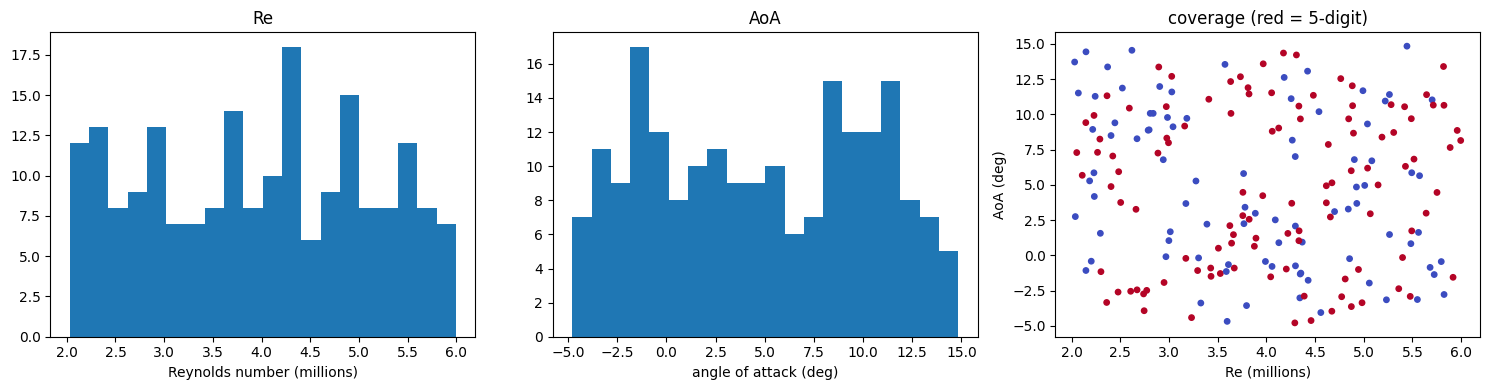

Re range 2.03–6.00 M,  AoA range -4.8–14.8 deg
4-digit: 89,  5-digit: 111


In [ ]:
sim0 = af.Simulation(root=ROOT, name=names[0])
NU = float(sim0.NU)          # kinematic viscosity of air used by the dataset (298.15 K)
print(f'nu = {NU:.3e} m^2/s')

meta = np.array([parse_name(n)[:2] for n in names])
Re = meta[:, 0] * 1.0 / NU        # chord = 1 m
n_digits = np.array([4 if len(parse_name(n)[2]) == 3 else 5 for n in names])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(Re / 1e6, bins=20); ax[0].set_xlabel('Reynolds number (millions)'); ax[0].set_title('Re')
ax[1].hist(meta[:, 1], bins=20); ax[1].set_xlabel('angle of attack (deg)'); ax[1].set_title('AoA')
ax[2].scatter(Re / 1e6, meta[:, 1], c=n_digits, cmap='coolwarm', s=15)
ax[2].set_xlabel('Re (millions)'); ax[2].set_ylabel('AoA (deg)'); ax[2].set_title('coverage (red = 5-digit)')
plt.tight_layout(); plt.show()
print(f'Re range {Re.min()/1e6:.2f}–{Re.max()/1e6:.2f} M,  AoA range {meta[:,1].min():.1f}–{meta[:,1].max():.1f} deg')
print(f'4-digit: {(n_digits==4).sum()},  5-digit: {(n_digits==5).sum()}')

This coverage defines the envelope inside which surrogate predictions can be expected to hold. It is the reference for the trust analysis in Phase 4, where optimized designs are located relative to the training data.

## 7. Flow fields
Velocity magnitude, pressure coefficient, and eddy-viscosity ratio $\nu_t/\nu$, shown over the full domain and near the airfoil. The point cloud is Delaunay-triangulated for plotting, with triangles inside the airfoil masked out.

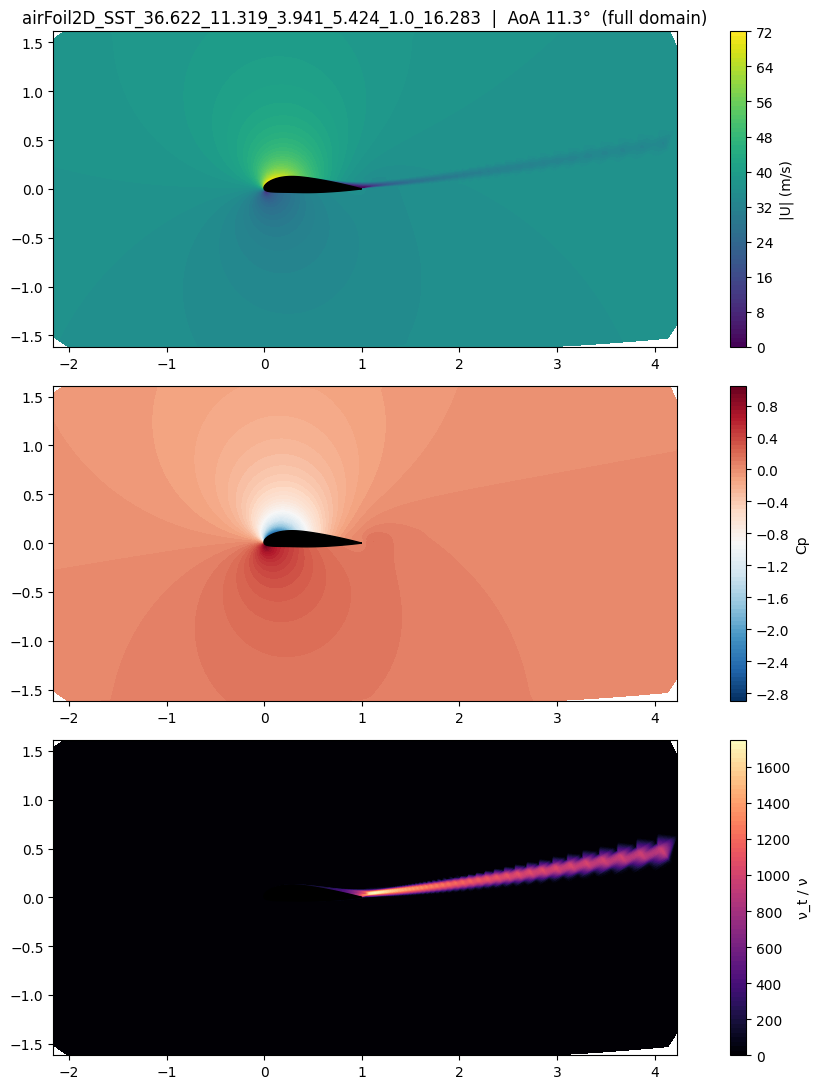

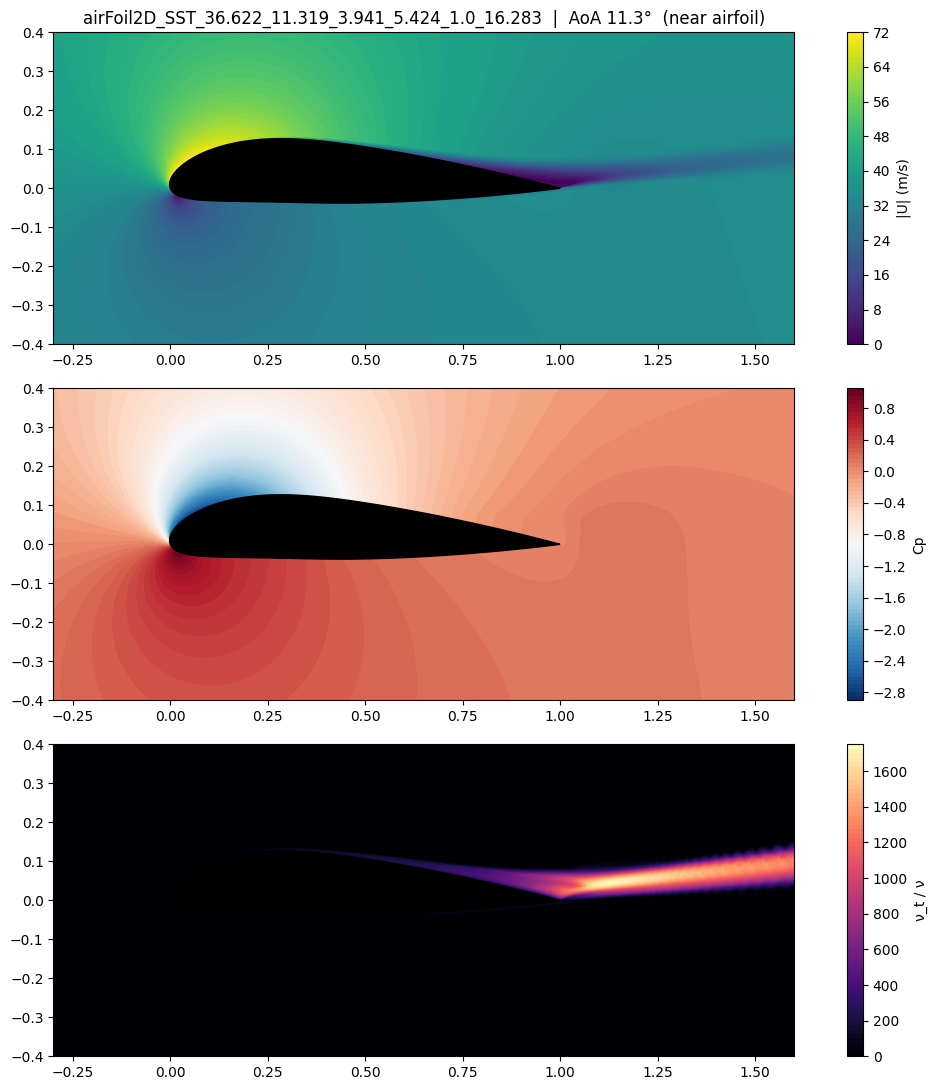

In [ ]:
import matplotlib.tri as mtri
from matplotlib.path import Path

pos, surf = d[:, :2], d[:, 11].astype(bool)
Umag = np.hypot(d[:, 7], d[:, 8])

# Triangulate the point cloud, then mask triangles that fall inside the airfoil
tri = mtri.Triangulation(pos[:, 0], pos[:, 1])
sidx, _ = order_surface(pos[surf], d[surf, 5:7])
airfoil_outline = pos[surf][sidx]
cent = pos[tri.triangles].mean(axis=1)
tri.set_mask(Path(airfoil_outline).contains_points(cent))

fields = [(Umag, '|U| (m/s)', 'viridis'),
          (d[:, 9] / (0.5 * u_inf**2), 'Cp', 'RdBu_r'),
          (d[:, 10] / NU, 'ν_t / ν', 'magma')]

def field_plot(xlim, ylim, title_suffix):
    fig, axes = plt.subplots(3, 1, figsize=(11, 11))
    for ax, (f, lab, cmap) in zip(axes, fields):
        cf = ax.tricontourf(tri, f, levels=80, cmap=cmap)
        ax.fill(airfoil_outline[:, 0], airfoil_outline[:, 1], color='k')
        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
        plt.colorbar(cf, ax=ax, label=lab)
    axes[0].set_title(f'{name}  |  AoA {aoa_deg:.1f}°  {title_suffix}')
    plt.tight_layout(); plt.show()

field_plot((pos[:,0].min(), pos[:,0].max()), (pos[:,1].min(), pos[:,1].max()), '(full domain)')
field_plot((-0.3, 1.6), (-0.4, 0.4), '(near airfoil)')

The near-airfoil view shows the expected features: a stagnation region at the leading edge ($C_p \approx 1$), suction over the upper surface, and a turbulent wake downstream of the trailing edge.

## 8. Near-wall mesh resolution
Mesh edges extracted from the simulation file, shown for the whole airfoil and magnified at the leading and trailing edges.

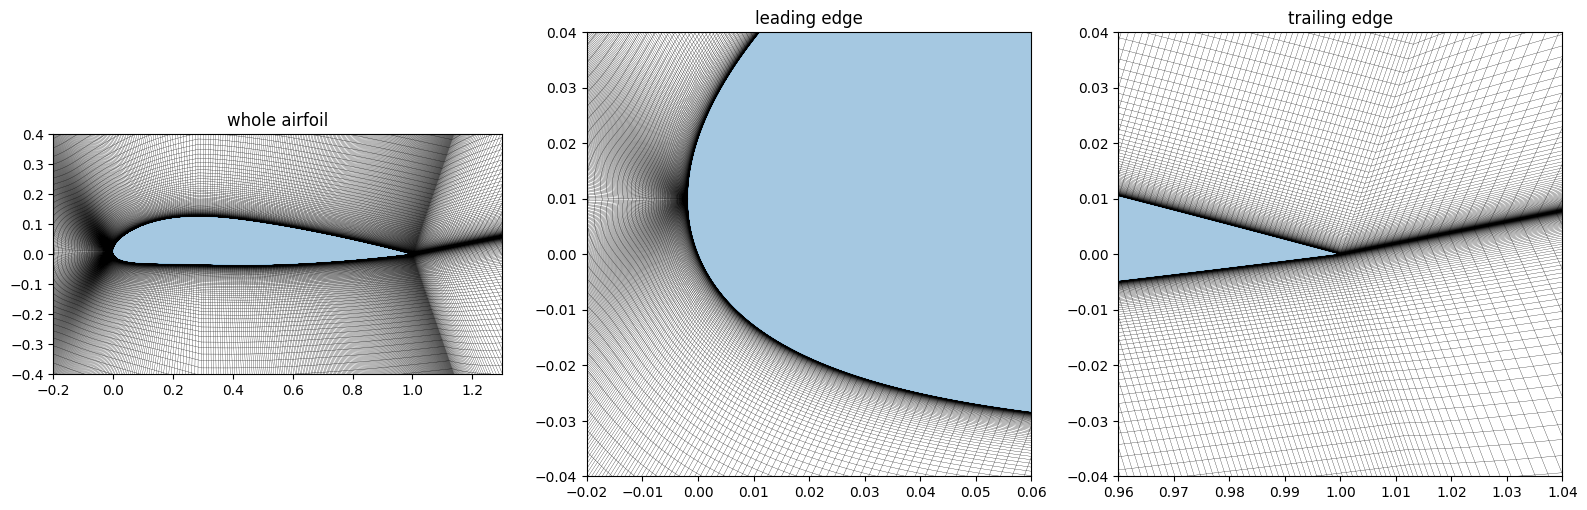

In [ ]:
from matplotlib.collections import LineCollection

def mesh_plot(ax, xlim, ylim):
    try:
        # Real mesh edges, from the simulation file
        edges = sim_i.internal.extract_all_edges()
        pts = np.asarray(edges.points)[:, :2]
        ln = np.asarray(edges.lines).reshape(-1, 3)[:, 1:]
        segs = pts[ln]
        keep = ((segs[:, :, 0] > xlim[0]) & (segs[:, :, 0] < xlim[1]) &
                (segs[:, :, 1] > ylim[0]) & (segs[:, :, 1] < ylim[1])).any(axis=1)
        ax.add_collection(LineCollection(segs[keep], linewidths=0.2, colors='k'))
    except Exception as e:
        print('edge extraction failed, showing nodes instead:', e)
        m = (pos[:,0]>xlim[0])&(pos[:,0]<xlim[1])&(pos[:,1]>ylim[0])&(pos[:,1]<ylim[1])
        ax.scatter(pos[m,0], pos[m,1], s=0.2, c='k')
    ax.fill(airfoil_outline[:, 0], airfoil_outline[:, 1], color='tab:blue', alpha=0.4)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')

sim_i = af.Simulation(root=ROOT, name=name)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mesh_plot(axes[0], (-0.2, 1.3), (-0.4, 0.4));        axes[0].set_title('whole airfoil')
mesh_plot(axes[1], (-0.02, 0.06), (-0.04, 0.04));    axes[1].set_title('leading edge')
mesh_plot(axes[2], (0.96, 1.04), (-0.04, 0.04));     axes[2].set_title('trailing edge')
plt.tight_layout(); plt.show()

The strong wall-normal clustering resolves the boundary layer. A pointwise surrogate sees these nodes only through their coordinates and small signed distance, so the near-wall region is expected to be the hardest to predict. This is examined explicitly in Phase 2.

## 9. Surface pressure distribution
$C_p$ along the upper and lower surfaces, with two consistency checks: the stagnation value should approach 1, and the far-field value should approach 0.

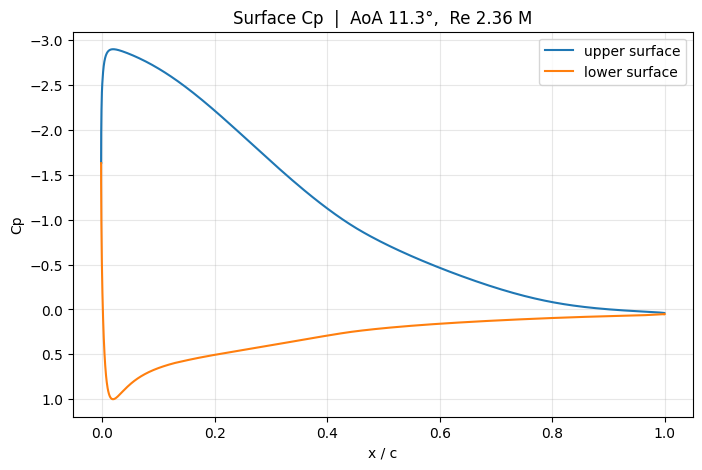

max Cp on surface: 1.001   (stagnation point, should be close to 1)
median Cp far from the airfoil: 0.006   (should be close to 0)


In [ ]:
sp, sn, spress = pos[surf], d[surf, 5:7], d[surf, 9]
idx, n_up = order_surface(sp, sn)
cp = spress[idx] / (0.5 * u_inf**2)
xs = sp[idx, 0]

plt.figure(figsize=(8, 5))
plt.plot(xs[:n_up], cp[:n_up], '-', label='upper surface')
plt.plot(xs[n_up:], cp[n_up:], '-', label='lower surface')
plt.gca().invert_yaxis()                 # aerodynamics convention: suction plotted upward
plt.xlabel('x / c'); plt.ylabel('Cp'); plt.grid(alpha=0.3); plt.legend()
plt.title(f'Surface Cp  |  AoA {aoa_deg:.1f}°,  Re {u_inf/NU/1e6:.2f} M')
plt.show()

# Sanity checks
far = d[:, 4] > np.percentile(d[:, 4], 99)
print(f'max Cp on surface: {cp.max():.3f}   (stagnation point, should be close to 1)')
print(f'median Cp far from the airfoil: {np.median(d[far, 9]) / (0.5*u_inf**2):.3f}   (should be close to 0)')

## 10. Force integration and validation
Surface pressure is integrated to pressure lift and drag directly from the raw arrays, which is the same form in which the surrogate will produce its predictions. The result is compared with `Simulation.force_coefficient()` from the `airfrans` library, which integrates over the airfoil surface mesh and also includes the viscous contribution.

Drag includes a substantial viscous contribution (about a third of the total in the case shown, and a larger share at low incidence), which a pressure-only integration omits. Only the pressure components are therefore compared directly; the viscous term will be taken into account in Phase 2.

In [ ]:
cd_p, cl_p = pressure_force_coefficients(sp, sn, spress, u_inf, np.radians(aoa_deg))
(cd, cdp_ref, cdv_ref), (cl, clp_ref, clv_ref) = sim_i.force_coefficient()

print(f'{"":22s}{"mine":>10s}{"library":>10s}')
print(f'{"CL (pressure part)":22s}{cl_p:10.4f}{clp_ref:10.4f}')
print(f'{"CD (pressure part)":22s}{cd_p:10.5f}{cdp_ref:10.5f}')
print(f'{"CL total":22s}{"":10s}{cl:10.4f}')
print(f'{"CD total":22s}{"":10s}{cd:10.5f}   (viscous part {cdv_ref:.5f})')

                            mine   library
CL (pressure part)        1.3878    1.3877
CD (pressure part)       0.01462   0.01510
CL total                            1.3882
CD total                           0.02276   (viscous part 0.00766)


Validation across multiple training cases:

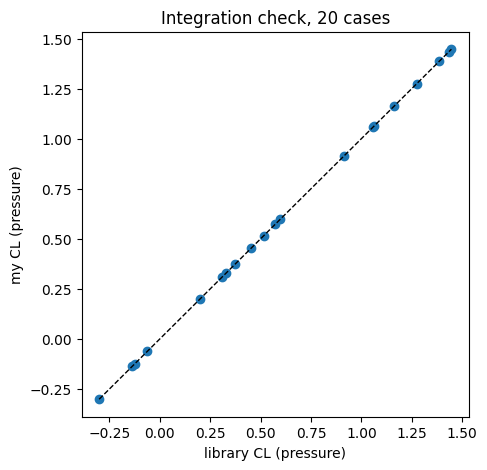

max abs CL difference: 0.0001


In [ ]:
# Repeat across 20 training cases to confirm it holds generally
rows = []
for k in range(20):
    dk, nk = data[k], names[k]
    uk, ak, _ = parse_name(nk)
    sk = dk[:, 11].astype(bool)
    _, clk = pressure_force_coefficients(dk[sk, :2], dk[sk, 5:7], dk[sk, 9], uk, np.radians(ak))
    (_, _, _), (clt, clpt, _) = af.Simulation(root=ROOT, name=nk).force_coefficient()
    rows.append((ak, clk, clpt, clt))
rows = np.array(rows)
plt.figure(figsize=(5, 5))
plt.scatter(rows[:, 2], rows[:, 1])
lim = [rows[:, 1:3].min(), rows[:, 1:3].max()]
plt.plot(lim, lim, 'k--', lw=1)
plt.xlabel('library CL (pressure)'); plt.ylabel('my CL (pressure)'); plt.title('Integration check, 20 cases')
plt.show()
print('max abs CL difference:', np.abs(rows[:, 1] - rows[:, 2]).max().round(4))

Agreement on pressure lift establishes the integration error floor for the surrogate evaluation in Phase 2: any larger discrepancy in predicted $C_L$ is attributable to the model, not to post-processing.

## 11. Normalisation statistics
Per-feature mean and standard deviation, computed on the **training split only** (every 20th node, for speed) and saved for use in Phase 1.

In [ ]:
allpts = np.concatenate([dd[::20] for dd in data])      # every 20th node keeps this fast
stats = {c: (float(allpts[:, j].mean()), float(allpts[:, j].std()))
         for j, c in enumerate(COLS) if c != 'surface'}
for c, (m, s) in stats.items():
    print(f'{c:8s} mean {m:11.4g}   std {s:11.4g}')
out_dir = DRIVE_DIR if USE_DRIVE else '/content'
with open(f'{out_dir}/norm_stats_scarce.json', 'w') as f:
    json.dump(stats, f, indent=2)
print(f'saved {out_dir}/norm_stats_scarce.json')

x        mean      0.4989   std       0.703
y        mean     0.01148   std      0.3366
uinf_x   mean       60.93   std       17.33
uinf_y   mean       4.987   std       6.181
sdf      mean       0.231   std      0.4742
nx       mean    0.001693   std     0.04205
ny       mean   0.0003877   std     0.06387
Ux       mean       41.67   std       29.14
Uy       mean       9.971   std       30.01
p        mean      -410.4   std        2521
nut      mean   0.0008186   std    0.002973
saved /content/drive/MyDrive/airfrans/norm_stats_scarce.json


## Summary
* The *scarce* training split is loaded and characterised (sizes, mesh resolution, Reynolds number and angle-of-attack coverage).
* Flow-field, mesh, and surface-pressure visualisations reproduce the expected physical features.
* A pressure-integration routine operating on raw point data is validated against the library's reference implementation.
* Normalisation statistics are stored for surrogate training.

**Results.** The scarce training split loads 200 simulations with 158,276–200,695 mesh nodes each
(mean 179,538), about 1.7 GB in single precision. Note that this is considerably larger than the
~32,000 nodes sometimes quoted for AirfRANS; that figure is the number of nodes the published
baselines subsample per case during training. Surface pressure integration reproduces the
library's reference pressure lift to within 1 × 10⁻⁴ across twenty cases (1.3878 against 1.3877 on
the case shown), establishing the post-processing error floor for Phase 2. Pressure drag differs by
about 3 %, as expected for a small residual of large opposing forces computed by node-based
integration. The stagnation and far-field checks on the pressure coefficient both pass.

**Next : Phase 1:** a pointwise MLP baseline surrogate predicting $(U_x, U_y, p, \nu_t)$ at each mesh node, trained with per-field normalisation and per-epoch point subsampling.